
# MSIT 3103 · Assignment 3 Hotstart Notebook  
**Prompt Engineering Lab with Local Models (Ollama + LLaMA 3.2 1B)**

> Use this notebook to run structured prompt‑engineering experiments on a **local** small model (e.g., `llama3.2:1b` via Ollama).  
> You will implement Steps 1–4 (Basic → Structured → Few‑shot → CoT), collect outputs, and analyze results.



## 0) Local Environment Check

This notebook assumes you have **[Ollama](https://ollama.com/)** installed locally and the `llama3.2:1b` model available.

- Install Ollama: follow your OS‑specific steps from the website.  
- Pull the model (in a terminal):  
```bash
ollama pull llama3.2:1b
```
- Verify command works (from terminal): `ollama run llama3.2:1b "hello"`

> If you're executing this notebook on a machine without Ollama, use these cells as **documentation** and run the actual commands on your local machine. You can paste results back here for analysis.


In [1]:

import json, os, subprocess, time, uuid, textwrap
from dataclasses import dataclass, asdict
from typing import List, Dict

RESULTS_DIR = "a3_outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)

def ollama_run(model: str, prompt: str, options: Dict=None, timeout: int = 120) -> str:
    """Run a prompt through a local Ollama model via subprocess and return the text.

    Requires Ollama to be installed and available on PATH.

    """
    cmd = ["ollama", "run", model]
    if options:
        # Ollama CLI supports options via the JSON API; here we keep CLI simple.
        # For advanced options, consider using `ollama generate -m model -p prompt --options '{...}'` pattern.
        pass
    proc = subprocess.run(cmd, input=prompt.encode("utf-8"), stdout=subprocess.PIPE, stderr=subprocess.PIPE, timeout=timeout)
    if proc.returncode != 0:
        raise RuntimeError(f"Ollama error: {proc.stderr.decode('utf-8', errors='ignore')}")
    return proc.stdout.decode("utf-8", errors="ignore")

@dataclass
class Trial:
    step: str                 # basic / structured / fewshot / cot
    task_id: str              # arbitrary id of the task/question
    prompt: str
    response: str
    meta: Dict

def save_trials(trials: List[Trial], path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump([asdict(t) for t in trials], f, ensure_ascii=False, indent=2)
    print(f"Saved {len(trials)} trials to {path}")



## 1) Context Document & Tasks

Create/Load a short **context document** (few paragraphs) and a small set of **tasks** to query the model with.  
You may replace the placeholder context and tasks below with your own domain (e.g., finance, health, policy, product requirements).

> Keep **5–10 tasks** so runs complete quickly.


In [2]:

CONTEXT = """
Acme Coffee is launching a mobile ordering app. Users can customize drinks, save favorites, and schedule pickup.
New features include: seasonal drinks, reward points, referral codes, and a barista recommendation assistant.
The team tracks weekly KPIs: daily active users (DAU), average order value (AOV), and retention D7.
""".strip()

TASKS = [
    {"id": "t1", "question": "Summarize the key features of the Acme Coffee app."},
    {"id": "t2", "question": "List three KPIs and explain why they matter."},
    {"id": "t3", "question": "Propose two experiments to increase AOV."},
    {"id": "t4", "question": "Write a short FAQ answer: 'How do I redeem reward points?'"}
]

print(CONTEXT)
print("\nTasks:")
for t in TASKS:
    print("-", t["id"] + ":", t["question"])


Acme Coffee is launching a mobile ordering app. Users can customize drinks, save favorites, and schedule pickup.
New features include: seasonal drinks, reward points, referral codes, and a barista recommendation assistant.
The team tracks weekly KPIs: daily active users (DAU), average order value (AOV), and retention D7.

Tasks:
- t1: Summarize the key features of the Acme Coffee app.
- t2: List three KPIs and explain why they matter.
- t3: Propose two experiments to increase AOV.
- t4: Write a short FAQ answer: 'How do I redeem reward points?'



## 2) Step 1 — Basic Prompting

- Ask direct, simple questions grounded in the context document.
- Log correctness, completeness, and clarity for later comparison.


In [3]:

MODEL = "llama3.2:1b"

basic_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    basic_trials.append(Trial(step="basic", task_id=task["id"], prompt=prompt, response=resp, meta={}))

save_trials(basic_trials, os.path.join(RESULTS_DIR, "step1_basic.json"))


Saved 4 trials to a3_outputs/step1_basic.json


### Step 1 Observations — Basic Prompting

Overall, basic prompting produced fluent and generally complete answers for feature listing (t1) and KPI explanations (t2). The model also generated detailed experiment ideas for increasing AOV (t3), although some details (e.g., specific banners, dates, statistical tests) were not provided in the context.

The main weakness appeared in the FAQ task (t4): the model invented a redemption procedure involving a website/code/QR scan, which is not stated in the context. This is an example of **procedural hallucination**—the model fills in “common” steps even when the source document does not specify them.

In summary, Step 1 outputs were clear and well-written, but factual grounding was not consistently reliable when the task required specific process instructions.



## 3) Step 2 — Structured Output Prompts

- Instruct the model to output **strict JSON** or bullet lists/tables.
- Compare accuracy & reliability with Step 1.


In [4]:

structured_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Return the answer in **strict JSON** with keys:
- "answer": string
- "supporting_facts": list of short strings derived from the context
- "confidence": number in [0,1]

Context:
{CONTEXT}

Question:
{task['question']}

If something is unknowable from the context, set "confidence": 0 and use an empty "supporting_facts".
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    structured_trials.append(Trial(step="structured", task_id=task["id"], prompt=prompt, response=resp, meta={"format":"json"}))

save_trials(structured_trials, os.path.join(RESULTS_DIR, "step2_structured.json"))


Saved 4 trials to a3_outputs/step2_structured.json


### Step 2 Observations — Structured Output Behavior

The structured prompting approach required the model to return strict JSON with specific keys. While the model attempted to follow the format, several formatting violations were observed:

- Some responses included markdown code fences (```json ... ```), which violates the "strict JSON only" instruction.
- In task t2, the model returned JSON followed by additional explanatory text outside the JSON block.
- In task t3, the model returned two separate JSON objects instead of a single structured response.
- Supporting facts sometimes included information not explicitly stated in the context.

Compared to Step 1 (basic prompting), structured prompting increased output consistency in format but introduced partial compliance issues. This demonstrates that smaller models (1B scale) struggle with strict schema adherence, even when explicitly instructed.

Overall, structured prompts improved output organization but did not fully eliminate hallucination or formatting errors.



## 4) Step 3 — Few‑shot Prompting

- Provide **1–3 short examples** to steer the style & content.
- Compare results with Steps 1–2.


In [5]:

FEW_SHOT_EXAMPLES = [
    {
        "q": "List two seasonal drinks in the app and describe them briefly.",
        "a": "- Pumpkin Spice Latte: spiced espresso with milk\n- Peppermint Mocha: minty chocolate espresso"
    },
    {
        "q": "Explain what DAU means.",
        "a": "Daily Active Users; the number of unique users opening the app on a given day."
    }
]

def render_fewshot_block(examples):
    parts = ["You are a helpful assistant. Here are some QA examples:"]
    for ex in examples:
        parts.append(f"Q: {ex['q']}\nA: {ex['a']}")
    return "\n\n".join(parts)

fewshot_prefix = render_fewshot_block(FEW_SHOT_EXAMPLES)

fewshot_trials = []
for task in TASKS:
    prompt = f"""
{fewshot_prefix}

Now answer the new question using the context below.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    fewshot_trials.append(Trial(step="fewshot", task_id=task["id"], prompt=prompt, response=resp, meta={"k": len(FEW_SHOT_EXAMPLES)}))

save_trials(fewshot_trials, os.path.join(RESULTS_DIR, "step3_fewshot.json"))


Saved 4 trials to a3_outputs/step3_fewshot.json


### Step 3 Observations — Few-shot Prompting

Few-shot examples noticeably influenced the response style: outputs became more concise and list-oriented, especially for t1, compared to Step 1 (basic prompting).

However, the few-shot setting also introduced **content drift**:
- In t1, the model incorrectly listed KPI tracking as an app “feature,” even though KPIs are internal metrics rather than user-facing features.
- It also rewrote “Retention D7” as “retention Daily 7,” showing minor terminology distortion.

For t4 (FAQ), the model still hallucinated details not present in the context (e.g., “coffee cupcake,” “App ID and password,” and navigation steps unrelated to reward redemption). This suggests few-shot prompting improved structure and brevity, but did not reliably prevent unsupported procedural details.



## 5) Step 4 — Chain‑of‑Thought (CoT) Prompting

- Encourage explicit reasoning (e.g., _"Let's think step by step."_).  
- Compare reasoning quality, correctness, and verbosity with prior steps.

> **Note:** When writing your report, avoid pasting raw CoT traces if disallowed by an evaluation policy. Summarize the reasoning instead.


In [6]:

cot_trials = []
for task in TASKS:
    prompt = f"""
You are a helpful assistant. Let's think step by step and show reasoning before the final answer.
Use the context to avoid hallucinations. Provide a short final answer at the end under 'Final Answer: ...'.

Context:
{CONTEXT}

Question:
{task['question']}
""".strip()
    try:
        resp = ollama_run(MODEL, prompt)
    except Exception as e:
        resp = f"[ERROR running model locally] {e}"
    cot_trials.append(Trial(step="cot", task_id=task["id"], prompt=prompt, response=resp, meta={"cot": True}))

save_trials(cot_trials, os.path.join(RESULTS_DIR, "step4_cot.json"))


Saved 4 trials to a3_outputs/step4_cot.json


### Step 4 Observations — Chain-of-Thought (CoT) Prompting

- **t1 (Features):** CoT led the model to focus on the core user-facing features (customization, favorites, scheduled pickup). However, it omitted some “new features” mentioned in the context (seasonal drinks, reward points, referral codes, recommendation assistant), so completeness decreased compared to Step 1.

- **t2 (KPIs):** The output was clear and largely correct. CoT helped produce structured explanations for DAU, AOV, and D7 retention, and the answer stayed grounded in the context.

- **t3 (AOV experiments):** The model proposed plausible ideas, but it introduced unsupported implementation details (e.g., customer review system and a recommendation algorithm design) that were not stated in the context. CoT improved organization, but did not fully prevent hallucinated operational steps.

- **t4 (Reward redemption FAQ):** The model still hallucinated a detailed redemption workflow (rewards catalog, email notification, date/time selection), none of which is provided in the context. CoT did not reduce procedural hallucination in this task.

Overall, CoT improved clarity and structure for reasoning-style questions (t2/t3), but it did not consistently improve factual grounding, and it sometimes reduced coverage of context-listed features (t1).



## 6) Scoring Scaffold (Manual or Programmatic)

Rate each response on:
- **Correctness** (0–5), **Completeness** (0–5), **Clarity** (0–5).  
Optionally mark factual errors.

Fill the table below manually (or write a simple heuristic scorer).


In [7]:

import json, glob, pandas as pd

def load_trials(pattern):
    rows = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        for item in data:
            rows.append({
                "file": os.path.basename(path),
                "step": item["step"],
                "task_id": item["task_id"],
                "prompt": item["prompt"],
                "response": item["response"],
            })
    return pd.DataFrame(rows)

df = load_trials(os.path.join(RESULTS_DIR, "step*.json"))
df.head()


,file,step,task_id,prompt,response
0,step1_basic.json,basic,t1,You are a helpful assistant.\n\nContext:\nAcme...,Here are the key features of the Acme Coffee m...
1,step1_basic.json,basic,t2,You are a helpful assistant.\n\nContext:\nAcme...,Here are three key KPIs for Acme Coffee's mobi...
2,step1_basic.json,basic,t3,You are a helpful assistant.\n\nContext:\nAcme...,"As a helpful assistant, I'd be happy to propos..."
3,step1_basic.json,basic,t4,You are a helpful assistant.\n\nContext:\nAcme...,"Here's a possible FAQ answer:\n\n""Q: How do I ..."
4,step2_structured.json,structured,t1,You are a helpful assistant. Return the answer...,"```\n{\n ""answer"": ""Acme Coffee's mobile orde..."


In [8]:

# Add scoring columns and export a CSV for manual rating
df_scores = df.copy()
for col in ["correctness_0_5", "completeness_0_5", "clarity_0_5", "notes"]:
    if col not in df_scores.columns:
        df_scores[col] = ""

out_csv = os.path.join(RESULTS_DIR, "ratings_template.csv")
df_scores.to_csv(out_csv, index=False)
out_csv


'a3_outputs/ratings_template.csv'


## 7) Aggregate & Compare

After you fill in `ratings_template.csv`, re‑import and compute per‑step averages.


In [9]:

import pandas as pd, numpy as np

ratings_path = os.path.join(RESULTS_DIR, "ratings_template.csv")
ratings = pd.read_csv(ratings_path)

def to_num(x):
    try:
        return float(x)
    except:
        return np.nan

ratings["correctness_0_5"] = ratings["correctness_0_5"].apply(to_num)
ratings["completeness_0_5"] = ratings["completeness_0_5"].apply(to_num)
ratings["clarity_0_5"] = ratings["clarity_0_5"].apply(to_num)

summary = ratings.groupby("step")[["correctness_0_5","completeness_0_5","clarity_0_5"]].mean().round(2)
summary


,correctness_0_5,completeness_0_5,clarity_0_5
step,,,
basic,3.25,4.75,4.25
cot,3.50,4.00,4.50
fewshot,3.00,4.25,4.50
structured,2.50,2.75,3.50



## 8) Visualization

Plot average scores by step (Basic vs Structured vs Few‑shot vs CoT).


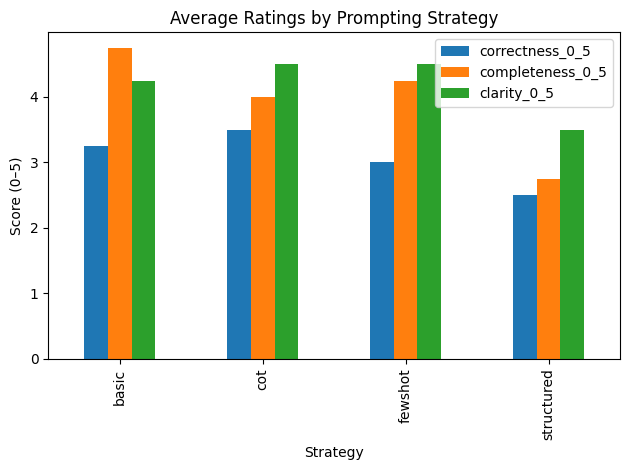

In [10]:

import matplotlib.pyplot as plt

summary.plot(kind="bar")
plt.title("Average Ratings by Prompting Strategy")
plt.ylabel("Score (0–5)")
plt.xlabel("Strategy")
plt.tight_layout()
plt.show()


### Interpretation of Visualization Results

The visualization highlights clear differences between prompting strategies across correctness, completeness, and clarity.

Basic prompting achieved strong completeness (4.75) and clarity (4.25), indicating that direct questions produced detailed and readable responses. However, correctness (3.25) was moderate due to occasional hallucinated procedural details.

Chain-of-Thought (CoT) prompting slightly improved correctness (3.50) and achieved the highest clarity score (4.50). The step-by-step reasoning appeared to help structure explanations, but it did not fully eliminate unsupported assumptions.

Few-shot prompting improved clarity (4.50) but slightly reduced correctness (3.00). The model imitated the style of examples but introduced content drift, such as misclassifying internal KPIs as user-facing features.

Structured prompting performed the weakest overall (correctness: 2.50, completeness: 2.75). The model frequently violated strict JSON formatting requirements, reducing reliability despite the added constraints.

Overall, CoT provided the most balanced performance, while structured prompting showed that smaller models struggle under rigid output constraints.


## Final Conclusion

This experiment demonstrates that prompt engineering significantly affects small local model performance (LLaMA 3.2 1B).

Basic prompting produced strong completeness but allowed hallucinated details. Few-shot prompting improved stylistic control, yet introduced content drift and minor terminology distortions. Chain-of-Thought prompting improved structural clarity and slightly increased factual grounding, making it the most balanced strategy in this setting.

Structured output prompting revealed an important limitation: small models struggle with strict formatting constraints. The frequent JSON violations suggest that rigid output control may reduce reliability when model capacity is limited.

From a practical standpoint:

- Use **basic prompting** for quick, general responses.
- Use **few-shot prompting** when style alignment is important.
- Use **Chain-of-Thought prompting** when reasoning depth and structured explanation are required.
- Avoid overly rigid structured formats unless model size and instruction tuning are sufficient.

These findings highlight that prompt engineering is not only about adding complexity, but about matching prompt strategy to model capability and task requirements.
